# S&P 500 Equity Option Analytics: Feature Evaluation

This case study has now built two feature sets: the eight families
`03_financial_features` derives from the option surface and the share price -
cross-sectional ranks, implied-volatility level and dynamics, skew and term
structure, the variance risk premium, realized volatility, equity momentum and
surface quality - and the three conditional-volatility estimators
`04_model_based_features` fits with a GJR-GARCH model. This notebook screens
every one of them, one at a time, against the forward equity return the
configuration names as the primary label.

The statistic it turns on is the **information coefficient**: on each session,
the rank correlation across names between a feature's value and the return that
follows it. One number per session gives a series, and the series answers three
questions in turn - does the feature rank names in the order their returns turn
out to, does it do so in every walk-forward validation window or only in one,
and what does having tested the whole candidate set at once cost the
credibility of whichever looks best. The output is one recorded decision per
feature.

Both upstream notebooks say the question of whether a feature predicts belongs
here, and neither screens for it. Nothing downstream applies the answer: the
models from Ch11 on train on the whole feature matrix and let regularization
sort it out. A recorded STOP is a judgment about a feature, not a filter applied
on the reader's behalf.

Every statistic below is computed on development sessions only. The 2021 holdout
is never read here; it is spent once, on the single selected configuration, in
Ch20.

**Learning objectives**

- Measure whether a candidate ranks names in the order their next-week returns
  turn out to, by taking one rank correlation across names per session and
  averaging the series that gives you.
- Widen the uncertainty of that average to account for consecutive five-day
  returns covering four of the same five days, which makes neighbouring
  sessions carry nearly the same information.
- Adjust the significance of a whole set of simultaneous tests so the number of
  features called predictive is not simply the number you would expect from
  testing that many.
- Separate a candidate whose association holds in both validation windows from
  one that reverses between them, and record which of the two each feature is.

**Book Reference**: §7.3 (univariate feature-label evaluation) and §7.4 (search
accounting and multiple testing). §8.6 is the secondary reference for search
control.

**What it reads**: `features/financial.parquet`, `features/model_based.parquet`,
`labels/fwd_ret_5d.parquet`, and the evaluation block of `config/setup.yaml`.

**What it writes**: `evaluation/triage_ledger.parquet`, one row per feature,
read by `20_strategy_synthesis/02_feature_evaluation.py`, which puts the nine
case studies' screens side by side; and `evaluation/ic_timeseries.parquet`, the
per-session series the figures below are drawn from, at the grain they are
summarized out of.

**Prerequisites**: `03_financial_features.py` and `04_model_based_features.py`
must have run.

In [1]:
"""S&P 500 Equity Option Analytics: Feature Evaluation."""

import warnings
from datetime import date

import numpy as np
import plotly.graph_objects as go
import polars as pl
import yaml
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats, compute_ic_uncertainty
from ml4t.diagnostic.signal import monotonicity_score, quantize_factor
from plotly.subplots import make_subplots
from scipy.stats import spearmanr
from scipy.stats import t as student_t

import utils.style as style
from case_studies.utils.cv_window import modeling_fold_boundaries
from case_studies.utils.feature_engineering import (
    assign_families,
    families_from_config,
    register_frame,
)
from utils.cv_splits import load_evaluation_config
from utils.data_quality import validate_modeling_inputs
from utils.paths import display_path, get_case_study_dir

# Narrow, not blanket: the estimator's own missing-bandwidth warning stays visible.
warnings.filterwarnings("ignore", category=FutureWarning)

# Register the ML4T Plotly template (colorway, fonts, gridlines) as the default
# and expose the book palette so every figure sources color from utils.style.
style.apply_ml4t_style()
COLORS = style.COLORS
GRAY_FILLS = style.GRAY_FILLS

In [2]:
MAX_SYMBOLS = 0

## Configuration

Two kinds of constant, and the difference matters when a reader adapts this to
their own data. The first kind describes the case study and is read from
`config/setup.yaml`, so changing it there moves this notebook with it: which
label is primary, how far forward that label looks, when the holdout begins,
and which feature families the matrix is supposed to contain. The second kind
is this screen's own judgment about how much coverage, stability or effect size
is enough, and there is no configuration file that can settle those - they are
stated here, and each is displayed below with the decision it makes.

The smallest cross-section a rank correlation may be taken on is one of them.
Below it the correlation is an ordering of too few names to mean anything, and
the session is left out of the average rather than entered into it. A reduced
run loads fewer symbols than production does, so the floor is capped by the
universe actually loaded once the panel exists, and the gate shrinks with the
data instead of silently excluding every session.

In [3]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
EVAL_DIR = CASE_DIR / "evaluation"
EVAL_DIR.mkdir(exist_ok=True)

JOIN_COLS = ["timestamp", "symbol"]
DATE_COL = "timestamp"

setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
PRIMARY_LABEL = setup["labels"]["primary"]
PRIMARY_LABEL_FILE = f"{PRIMARY_LABEL}.parquet"
# `5D` -> 5 sessions. The horizon is spent twice: it sets how many development
# sessions are dropped at the holdout boundary, and it sets the bandwidth of the
# Newey-West correction in section 2.
LABEL_HORIZON_SESSIONS = int(str(setup["labels"]["horizons"][PRIMARY_LABEL]).rstrip("Dd"))
HAC_MAXLAGS = LABEL_HORIZON_SESSIONS
FEATURE_FAMILIES = families_from_config(setup)
GARCH_FAMILY = "conditional volatility"

# This screen's own bounds.
COVERAGE_MIN = 0.70
STALENESS_MAX = 0.50
FDR_ALPHA = 0.05
SIGN_CONSISTENCY_MIN = 0.60
REDUNDANCY_CUT = 0.70
IC_THRESHOLD = 0.005
N_QUANTILES = 5
MIN_CROSS_SECTION_DEFAULT = 20  # capped by the universe actually loaded, below
NON_FEATURE_COLS = {"fold", "is_holdout"}  # keys and flags, not candidates

In [4]:
print("Read from config/setup.yaml - what this case study is:")
print(
    f"  The primary label is {PRIMARY_LABEL}, the return over the next "
    f"{LABEL_HORIZON_SESSIONS} sessions. Every feature is screened against it, and "
    f"because two labels one session apart cover {LABEL_HORIZON_SESSIONS - 1} of the "
    f"same {LABEL_HORIZON_SESSIONS} sessions, the significance test has to price that "
    f"overlap in."
)
print(
    f"  The holdout begins {setup['evaluation']['holdout_start']}. No statistic here "
    f"may reach it, either directly or through a label that settles after it."
)
print(
    f"  The walk-forward scheme declares {setup['evaluation']['n_splits']} folds. That "
    f"is how many separate windows a feature has to agree with itself across, and this "
    f"is as few as such a test can have."
)
print("\nThis screen's own bounds - how much is enough:")
print(
    f"  A feature is dropped before its association is measured unless at least "
    f"{COVERAGE_MIN:.0%} of its rows carry a value, because the names a thin surface "
    f"is missing are not a random sample of the universe."
)
print(
    f"  It is also dropped if more than {STALENESS_MAX:.0%} of its rows repeat the "
    f"previous session's value, which is what a stopped feed looks like and would "
    f"show up as a correlation that is really the carry-forward."
)
print(
    f"  Of the features this notebook ends up calling predictive, it accepts that up "
    f"to {FDR_ALPHA:.0%} of them are false."
)
print(
    f"  Fold agreement is set at {SIGN_CONSISTENCY_MIN:.0%} of folds sharing the "
    f"feature's own sign; with two folds that is a yes or no, not a proportion."
)
print(
    f"  The effect-size floor for promotion without significance is a mean absolute "
    f"information coefficient of {IC_THRESHOLD}; section 3 says what sets the level."
)
print(
    f"  Two features are treated as one ordering under two names once their rank "
    f"correlation exceeds {REDUNDANCY_CUT} in absolute value, and only one of them "
    f"then stands for the pair."
)

Read from config/setup.yaml - what this case study is:
  The primary label is fwd_ret_5d, the return over the next 5 sessions. Every feature is screened against it, and because two labels one session apart cover 4 of the same 5 sessions, the significance test has to price that overlap in.
  The holdout begins 2021-01-01. No statistic here may reach it, either directly or through a label that settles after it.
  The walk-forward scheme declares 2 folds. That is how many separate windows a feature has to agree with itself across, and this is as few as such a test can have.

This screen's own bounds - how much is enough:
  A feature is dropped before its association is measured unless at least 70% of its rows carry a value, because the names a thin surface is missing are not a random sample of the universe.
  It is also dropped if more than 50% of its rows repeat the previous session's value, which is what a stopped feed looks like and would show up as a correlation that is really the car

## 0. Load the artifacts and build the evaluation panel

Three artifacts: the financial features from `03_financial_features`, the
conditional-volatility estimators from `04_model_based_features`, and the
primary label. The financial columns are deterministic transforms of observable
prices and surfaces, one row per `(timestamp, symbol)`, and they join straight
on.

**The model-based artifact does not.** A **walk-forward fold** is one
training window followed by the validation window immediately after it, and the
scheme steps both windows forward to make the next fold. `04_model_based_features`
refits its GJR-GARCH model inside each fold's training window, so
`model_based.parquet` carries one row per `(timestamp, symbol, fold)` - the same
date and name once per fold, with a different set of fitted parameters each
time. Each fold's rows span its training window as well as its validation
window, and only the validation half is out of sample: inside the training
window, the fitted value at a date was estimated from a span that includes that
date and everything after it up to the training end. The extra fold that trains
on the whole development window is the sharpest case - its rows dated 2019 carry
parameters estimated from data through 2020.

Joining that frame on `(timestamp, symbol)` alone would do two things at once.
It would **duplicate panel rows**, because the key is not unique on the right
side, so a name would appear once per fold in the same cross-section and be
counted that many times by every statistic below - including the staleness
screen, which would see the duplicates as adjacent identical rows and read them
as a column that does not move. And it would **mix fold provenance**, because
whichever of those rows a later cell read might be an in-sample fitted value.

So the model-based frame is cut down to each fold's validation window before it
is joined, and the result is checked for one row per key rather than assumed to
have it. The consequence is that the GARCH columns exist only where a fold
validated them, which is the later part of the development window and not all of
it - and the screens in section 1 measure them on that window rather than
against a denominator they cannot reach.

In [5]:
features = pl.read_parquet(CASE_DIR / "features" / "financial.parquet")
temporal = pl.read_parquet(CASE_DIR / "features" / "model_based.parquet")
label_df = pl.read_parquet(CASE_DIR / "labels" / PRIMARY_LABEL_FILE)

for name, frame in (("financial", features), ("model_based", temporal), (PRIMARY_LABEL, label_df)):
    missing = sorted(set(JOIN_COLS) - set(frame.columns))
    if missing:
        msg = f"{name} does not carry the canonical key columns {missing}: {frame.columns}"
        raise KeyError(msg)

label_col = next(c for c in label_df.columns if c not in JOIN_COLS)
cv_config = load_evaluation_config(CASE_STUDY_ID)

print(f"Financial features: {features.shape[0]:,} rows x {features.shape[1]} columns")
print(f"Model-based features: {temporal.shape[0]:,} rows x {temporal.shape[1]} columns")
print(f"Label {label_col}: {label_df.shape[0]:,} rows")

Financial features: 481,184 rows x 47 columns
Model-based features: 1,098,328 rows x 6 columns
Label fwd_ret_5d: 632,522 rows


In [6]:
financial_cols = [c for c in features.columns if c not in JOIN_COLS and c not in NON_FEATURE_COLS]
temporal_cols = [c for c in temporal.columns if c not in JOIN_COLS and c not in NON_FEATURE_COLS]

# The producer folds, from the same generator stage 04 called, so a fold id means
# the same thing on both sides. The extra whole-development-window fold stage 04
# appends is not in this list and is therefore never selected here.
producer_folds = modeling_fold_boundaries(CASE_STUDY_ID, PRIMARY_LABEL)
if not producer_folds:
    msg = f"No canonical modeling folds for {CASE_STUDY_ID}/{PRIMARY_LABEL}"
    raise RuntimeError(msg)

temporal_oos = pl.concat(
    [
        temporal.filter(
            (pl.col("fold") == f["fold"])
            & (pl.col(DATE_COL) >= f["val_start"])
            & (pl.col(DATE_COL) <= f["val_end"])
        )
        for f in producer_folds
    ]
).drop("fold")
if temporal_oos.select(JOIN_COLS).n_unique() != len(temporal_oos):
    msg = "Fold validation windows overlap: the out-of-sample frame is not one row per key"
    raise ValueError(msg)

# The window the GARCH columns can be screened on. Outside it they are absent by
# construction rather than missing, and section 1 divides by this rather than by
# the whole development panel.
TEMPORAL_WINDOW = (
    min(f["val_start"] for f in producer_folds),
    max(f["val_end"] for f in producer_folds),
)

for f in producer_folds:
    print(
        f"fold {f['fold']}: fitted {f['train_start']} to {f['train_end']}, "
        f"kept {f['val_start']} to {f['val_end']}"
    )
print(
    f"Model-based rows: {len(temporal):,} across all folds -> {len(temporal_oos):,} taken "
    f"from validation windows only ({TEMPORAL_WINDOW[0]} to {TEMPORAL_WINDOW[1]})"
)

# Left join, so the panel keeps every financial row and the GARCH columns arrive
# as nulls outside the validation windows. The row count is checked rather than
# trusted: a right side with a duplicate key would silently multiply the panel.
eval_panel = features.join(temporal_oos, on=JOIN_COLS, how="left")
if len(eval_panel) != len(features):
    msg = f"Model-based join changed the panel row count: {len(features):,} -> {len(eval_panel):,}"
    raise ValueError(msg)
eval_panel = eval_panel.join(label_df, on=JOIN_COLS, how="inner")

all_feature_cols = financial_cols + temporal_cols

if MAX_SYMBOLS > 0:
    top = eval_panel.group_by("symbol").len().sort("len", descending=True).head(MAX_SYMBOLS)
    eval_panel = eval_panel.filter(pl.col("symbol").is_in(top["symbol"]))

fold 0: fitted 2018-01-04 to 2019-12-18, kept 2020-01-06 to 2020-12-23
fold 1: fitted 2017-01-05 to 2018-12-19, kept 2019-01-07 to 2020-01-03
Model-based rows: 1,098,328 across all folds -> 233,572 taken from validation windows only (2019-01-07 to 2020-12-23)


### Hold back the 2021 window, and the sessions whose labels reach it

Both upstream notebooks leave the question of predictive content to this one, so
every statistic below - coverage, staleness, the information coefficient and its
significance, the multiplicity adjustment, fold stability and the triage - is
computed on development sessions only.

Dropping sessions dated in 2021 is not enough on its own. The label attached to a
decision made on the last development session is the return over the five
sessions that follow it, which are 2021 sessions, so that decision already knows
something about the held-back period. The last five development sessions are
therefore dropped as well. This is called an **embargo**: a gap wide enough that
no observation kept on one side of the boundary has an outcome resolved on the
other. Its width is the label's own horizon, and it is counted in sessions on
this panel's own trading calendar rather than in calendar days.

In [7]:
holdout_start = str(cv_config["holdout_start"])[:10]
holdout_start_date = date.fromisoformat(holdout_start)

dev_sessions = eval_panel.filter(pl.col(DATE_COL) < holdout_start_date)[DATE_COL].unique().sort()
if dev_sessions.len() > LABEL_HORIZON_SESSIONS:
    embargo_cutoff = dev_sessions[-(LABEL_HORIZON_SESSIONS + 1)]
    eval_panel = eval_panel.filter(pl.col(DATE_COL) <= embargo_cutoff)
else:
    eval_panel = eval_panel.filter(pl.col(DATE_COL) < holdout_start_date)

print(
    f"Holdout begins {holdout_start}. Evaluating "
    f"{eval_panel[DATE_COL].min()} to {eval_panel[DATE_COL].max()}: "
    f"{eval_panel[DATE_COL].n_unique():,} development sessions, after a "
    f"{LABEL_HORIZON_SESSIONS}-session embargo at the boundary."
)

n_rows = len(eval_panel)
n_symbols = eval_panel["symbol"].n_unique()
n_dates = eval_panel[DATE_COL].n_unique()
MIN_CROSS_SECTION = min(MIN_CROSS_SECTION_DEFAULT, n_symbols)
print(
    f"Panel: {n_rows:,} rows, {n_symbols} symbols, {n_dates:,} sessions. "
    f"A session enters the average only with at least {MIN_CROSS_SECTION} names "
    f"carrying both the feature and the label."
)

Holdout begins 2021-01-01. Evaluating 2017-02-01 to 2020-12-23: 982 development sessions, after a 5-session embargo at the boundary.
Panel: 380,973 rows, 608 symbols, 982 sessions. A session enters the average only with at least 20 names carrying both the feature and the label.


### What is being screened

The candidate set is the register `config/setup.yaml` declares, one row per
family, plus the conditional-volatility columns from `04_model_based_features`.
The register is what fixes the searched set before any of it is tested: it says
which families exist, what each is built from and what it is supposed to
capture, and a column with no register row raises rather than being screened
under a name nobody declared. `lookback`
is how many sessions of history the family's longest window spans, and `lag` is
how late its input becomes knowable - one session for everything read off the
option surface, because the surface summary is stamped at the close it
summarizes and is not acted on until the next decision.

In [8]:
families = assign_families(financial_cols, FEATURE_FAMILIES) | dict.fromkeys(
    temporal_cols, GARCH_FAMILY
)
register = register_frame(FEATURE_FAMILIES, financial_cols).select(
    ["family", "columns", "role", "inputs", "lookback (bars)", "lag (bars)", "representation"]
)
print(
    f"{len(financial_cols)} financial features in {len(FEATURE_FAMILIES)} declared families, "
    f"plus {len(temporal_cols)} in {GARCH_FAMILY} from 04_model_based_features, "
    f"screened against {label_col}."
)
register

45 financial features in 8 declared families, plus 3 in conditional volatility from 04_model_based_features, screened against fwd_ret_5d.


family,columns,role,inputs,lookback (bars),lag (bars),representation
str,i64,str,str,i64,i64,str
"""cross-sectional rank""",8,"""signal""","""the eight level and dynamics c…",252,1,"""percentile within the date, in…"
"""implied volatility level""",5,"""signal""","""daily IV surface summary, delt…",1,1,"""annualized implied volatility,…"
"""implied volatility dynamics""",6,"""signal""","""at-the-money 30-day implied vo…",252,1,"""first difference, multi-sessio…"
"""skew and term structure""",10,"""signal""","""25-delta put and call IV, and …",63,1,"""differences and ratios between…"
"""variance risk premium""",2,"""signal""","""at-the-money implied volatilit…",63,1,"""spread in volatility points an…"
"""realized volatility""",5,"""state""","""split- and dividend-adjusted O…",63,0,"""annualized standard deviation,…"
"""equity momentum""",7,"""signal""","""split- and dividend-adjusted c…",252,0,"""simple return at five horizons…"
"""surface quality""",2,"""state""","""bid-ask spread and solver conv…",1,1,"""relative spread, and the share…"


## The artifact gate

One question before any feature is measured: is anything in these artifacts
broken outright - a non-finite value, a negative price, a return no equity could
have produced over a week? That is a property of the files, and it is separate
from the per-feature coverage and staleness screens in section 1, which ask
whether a column that is intact is also usable.

The bound on the label is the one judgment in this gate. A share that trebles or
loses two thirds of its value in a week is possible and rare; a share that moves
several hundred percent in a week is a corporate action the price series failed
to adjust for, entering the label as if it were a return. So the bound is set
above what a market can plausibly do and below what an unadjusted split looks
like. Setting it at the largest move actually observed would make the gate fire
on the next genuine one; setting it an order of magnitude above would let the
artifact it exists to catch through.

In [9]:
MAX_ABS_LABEL_RETURN = 3.0

quality = validate_modeling_inputs(
    features_df=eval_panel,
    label_df=eval_panel,
    feature_cols=all_feature_cols,
    label_col=label_col,
    join_cols=JOIN_COLS,
    asset_col="symbol",
    max_abs_return=MAX_ABS_LABEL_RETURN,
    fail_on_critical=True,
)
print(
    f"Largest absolute {label_col} in the panel: "
    f"{eval_panel[label_col].abs().max():.3f}, against a bound of {MAX_ABS_LABEL_RETURN}."
)
print(f"Critical issues: {quality['n_critical']}, warnings: {quality['n_warning']}")

Data Quality Gate: ALL CLEAR
Largest absolute fwd_ret_5d in the panel: 1.112, against a bound of 3.0.
Critical issues: 0, warnings: 0


## 1. Can the definition be trusted?

Two properties a feature has whether or not it predicts anything, and both have
to hold before measuring whether it does. **Coverage** is the share of rows
carrying a value at all. **Staleness** is the share of rows repeating the same
name's previous session, which is what a feed that has stopped updating looks
like from the inside. Book §7.3 lists four correctness questions; these are two
of them, and the other two - timing and lag consistency, and mask alignment -
are settled where each family's lag is declared, in the register above.

Both matter here for reasons particular to option data. A surface summary exists
only for names with contracts quoted in the right maturity and delta buckets, so
the less-liquid half of the index carries fewer implied-volatility values than
the liquid half - and the names that go missing are not a random sample, which is
what makes low coverage a problem rather than a nuisance. And because every
surface-derived family is read one session late, a name whose surface did not
update carries yesterday's number forward; a correlation computed from a column
that mostly repeats itself is measuring the carry-forward.

A feature clears when its coverage reaches the floor and its staleness stays
under the ceiling, both printed with the configuration above. The figure shows
every candidate against both bounds, rather than only the ones that failed,
because where a feature sits relative to a bound is what tells the reader
whether the bound is doing any work.

**Each column is screened on the window it can reach.** For the financial
columns that is every development session. For the three GARCH columns it is
the union of the folds' validation windows, because outside that window stage 04
produced no out-of-sample fitted value, so the column is absent by construction
rather than missing. Dividing those by the whole development panel would report
the shape of the fold contract as though it were a data-quality failure, and the
gate would then drop them for a reason that is not true of them.

In [10]:
coverage = {}
staleness = {}

# The rows each column is eligible on. The GARCH columns exist only inside the
# folds' validation windows; everything else spans the panel.
eligible_rows = {}
for feat in all_feature_cols:
    if feat in temporal_cols:
        eligible_rows[feat] = eval_panel.filter(
            (pl.col(DATE_COL) >= TEMPORAL_WINDOW[0]) & (pl.col(DATE_COL) <= TEMPORAL_WINDOW[1])
        )
    else:
        eligible_rows[feat] = eval_panel

for feat in all_feature_cols:
    frame = eligible_rows[feat]
    denom = len(frame)
    coverage[feat] = frame[feat].drop_nulls().len() / denom

    unchanged = (
        frame.sort(JOIN_COLS)
        .select((pl.col(feat) == pl.col(feat).shift(1).over("symbol")).alias("same"))["same"]
        .sum()
    )
    staleness[feat] = float(unchanged) / max(denom - frame["symbol"].n_unique(), 1)

correctness = {
    feat: coverage[feat] >= COVERAGE_MIN and staleness[feat] <= STALENESS_MAX
    for feat in all_feature_cols
}
n_pass = sum(correctness.values())
n_fail = len(correctness) - n_pass
print(f"Cleared both bounds: {n_pass}. Failed at least one: {n_fail}.")

screened_out = pl.DataFrame(
    {
        "feature": [f for f, ok in correctness.items() if not ok],
        "family": [families[f] for f, ok in correctness.items() if not ok],
        "coverage": [round(coverage[f], 3) for f, ok in correctness.items() if not ok],
        "staleness": [round(staleness[f], 3) for f, ok in correctness.items() if not ok],
    }
).sort("coverage")
screened_out

Cleared both bounds: 36. Failed at least one: 12.


feature,family,coverage,staleness
str,str,f64,f64
"""term_ratio_z_63""","""skew and term structure""",0.028,0.0
"""d_term_ratio_atm""","""skew and term structure""",0.416,0.082
"""term_convexity""","""skew and term structure""",0.419,0.155
"""term_ratio_atm""","""skew and term structure""",0.427,0.158
"""iv_30_atm_pct_252""","""implied volatility dynamics""",0.457,0.004
…,…,…,…
"""iv_90_atm""","""implied volatility level""",0.534,0.076
"""vrp_z_63""","""variance risk premium""",0.592,0.0
"""iv_30_atm_z_63""","""implied volatility dynamics""",0.603,0.0


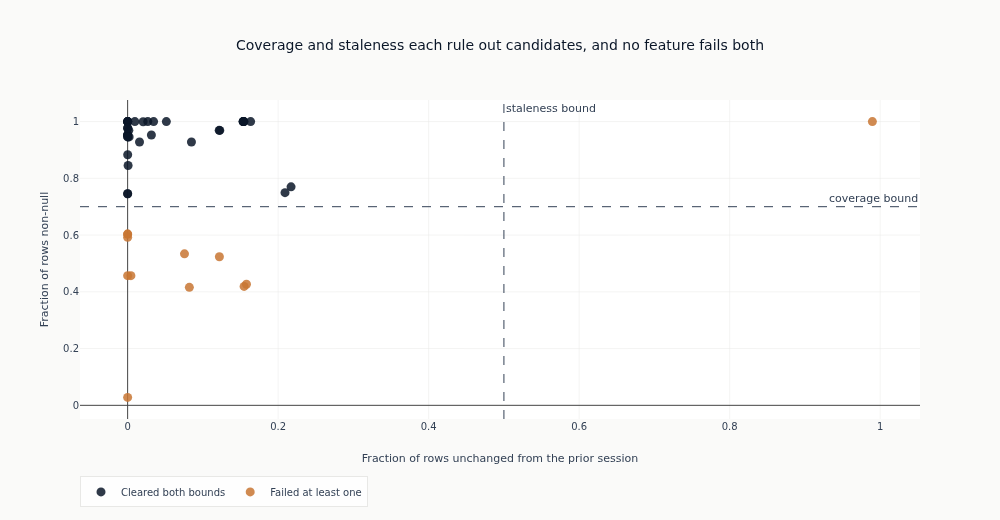

Failed on staleness alone: 1
Failed on coverage alone:  11
Failed on both:            0


In [11]:
fig = go.Figure()
for cleared, color, name in (
    (True, COLORS["blue"], "Cleared both bounds"),
    (False, COLORS["copper"], "Failed at least one"),
):
    members = [f for f in all_feature_cols if correctness[f] is cleared]
    if not members:
        continue
    _ = fig.add_trace(
        go.Scatter(
            x=[staleness[f] for f in members],
            y=[coverage[f] for f in members],
            mode="markers",
            marker={"color": color, "size": 9, "opacity": 0.85},
            text=members,
            name=name,
        )
    )
_ = fig.add_hline(
    y=COVERAGE_MIN,
    line={"color": COLORS["neutral"], "width": 1, "dash": "dash"},
    annotation_text="coverage bound",
)
_ = fig.add_vline(
    x=STALENESS_MAX,
    line={"color": COLORS["neutral"], "width": 1, "dash": "dash"},
    annotation_text="staleness bound",
)
fig.update_layout(
    title="Coverage and staleness each rule out candidates, and no feature fails both",
    xaxis_title="Fraction of rows unchanged from the prior session",
    yaxis_title="Fraction of rows non-null",
    height=520,
    width=1000,
    legend={"orientation": "h", "y": -0.18},
)
fig.show()
only_staleness = sum(
    1
    for f in all_feature_cols
    if not correctness[f] and coverage[f] >= COVERAGE_MIN and staleness[f] > STALENESS_MAX
)
only_coverage = sum(
    1
    for f in all_feature_cols
    if not correctness[f] and coverage[f] < COVERAGE_MIN and staleness[f] <= STALENESS_MAX
)
print(f"Failed on staleness alone: {only_staleness}")
print(f"Failed on coverage alone:  {only_coverage}")
print(f"Failed on both:            {n_fail - only_staleness - only_coverage}")

## 2. Does the feature carry information about the label?

The **information coefficient** is one number per session: the Spearman rank
correlation, across the names quoted that session, between a feature's value and
the return over the following week. Rank correlation rather than Pearson, because
what a long-short book acts on is the ordering of names, not the size of the gaps
between them - and because a single outlier cannot then set the answer. Averaging
that series over the development window gives the feature's mean information
coefficient, and the sections after this one ask how reliable that average is.

**Significance has to price in the overlap.** Two labels one session apart cover
four of the same five days, so consecutive information coefficients are not
independent draws, and the usual standard error of a mean - which assumes they
are - is too small. The **Newey-West** estimator replaces it with one that allows
neighbouring observations to be correlated up to a stated number of lags apart;
the bandwidth here is the label's own horizon, five sessions, which is exactly
the distance at which two labels stop sharing any days. It reads the series in
the order it is given, so the series is sorted by date before it is handed over.

A few columns describe the market as a whole rather than any one name, so they
take the same value across every symbol on a session. A cross-sectional
correlation of a constant is undefined, and this is not a defect in those
columns: they remain valid conditioning variables for a multivariate model. They
are separated out here rather than measured.

In [12]:
evaluable_features = [f for f in all_feature_cols if correctness[f]]

# A column with no cross-sectional dispersion on a typical session is a
# market-state variable, not a candidate for a cross-sectional ranking.
cs_std_df = eval_panel.group_by(DATE_COL).agg(
    [pl.col(f).std().alias(f) for f in evaluable_features]
)
date_level_features = set()
for feat in evaluable_features:
    mean_std = cs_std_df[feat].drop_nulls().mean()
    if mean_std is not None and mean_std < 1e-10:
        date_level_features.add(feat)

if date_level_features:
    print(f"Constant across names on a session, so not rankable: {sorted(date_level_features)}")

In [13]:
# One pass over sessions, every feature scored on each.
cs_features = [f for f in evaluable_features if f not in date_level_features]
cols_needed = [DATE_COL] + cs_features + [label_col]
eval_sub = eval_panel.select(cols_needed).drop_nulls(subset=[label_col])

dates_list = eval_sub[DATE_COL].unique().sort().to_list()
n_total = len(dates_list)

ic_series_data = {feat: [] for feat in cs_features}

for i, dt in enumerate(dates_list):
    cross_section = eval_sub.filter(pl.col(DATE_COL) == dt)
    n_obs = len(cross_section)
    if n_obs < MIN_CROSS_SECTION:
        continue

    label_arr = cross_section[label_col].to_numpy()
    label_valid = ~np.isnan(label_arr)

    for feat in cs_features:
        feat_arr = cross_section[feat].to_numpy()
        valid_mask = label_valid & ~np.isnan(feat_arr)
        n_valid = int(valid_mask.sum())
        if n_valid >= MIN_CROSS_SECTION:
            ic_val, _ = spearmanr(feat_arr[valid_mask], label_arr[valid_mask])
            if not np.isnan(ic_val):
                ic_series_data[feat].append((dt, float(ic_val), n_valid))

    if (i + 1) % 200 == 0:
        print(f"  scored {i + 1} of {n_total} sessions")

print(f"  scored {n_total} of {n_total} sessions")

  scored 200 of 982 sessions


  scored 400 of 982 sessions


  scored 600 of 982 sessions


  scored 800 of 982 sessions


  scored 982 of 982 sessions


In [14]:
MIN_SESSIONS_FOR_INFERENCE = 20

ic_results = {}
ic_timeseries = {}
for feat in cs_features:
    data = ic_series_data[feat]
    if len(data) < MIN_SESSIONS_FOR_INFERENCE:
        continue
    dates_f, ics_f, nobs_f = zip(*data, strict=False)
    ic_df = pl.DataFrame({DATE_COL: list(dates_f), "ic": list(ics_f), "n_obs": list(nobs_f)}).sort(
        DATE_COL
    )
    ic_results[feat] = compute_ic_hac_stats(ic_df, ic_col="ic", maxlags=HAC_MAXLAGS)
    ic_timeseries[feat] = ic_df

print(f"Mean information coefficient and its significance for {len(ic_results)} features.")

Mean information coefficient and its significance for 36 features.


### The series behind the average

A mean is a summary of a series, and the two things that decide whether a weak
association is usable are visible only in the series itself: an association
carried entirely by one episode, and one that changes sign partway through. The
left panel draws the session-by-session information coefficient of the strongest
feature under a rolling quarterly mean, so both patterns would show.

The right panel puts three ways of bounding the same average on one axis, for the
strongest features. The naive interval assumes each session is an independent
draw. The Newey-West interval allows neighbouring sessions to be correlated. The
block-bootstrap bounds resample contiguous runs of sessions rather than
individual ones, and so assume neither a variance formula nor a distribution.
With a five-session label the sessions overlap heavily, so the distance between
the grey band and the navy bar is what the independence assumption was buying,
and whether an interval still excludes zero once it is paid for is the whole
question this section asks.

The series drawn here is the one written to `evaluation/ic_timeseries.parquet`
at the end, at the grain everything below is summarized out of.

In [15]:
IC_ROLLING_WINDOW = 63  # one quarter of sessions
BOOT_BOUNDS = ("ci_boot_lower", "ci_boot_upper")

leaders = sorted(ic_results, key=lambda name: abs(ic_results[name]["mean_ic"]), reverse=True)[:8]
# The bands are asked for the same bandwidth the table above used. This call takes
# a horizon and sets its lag to one less, so it is handed one more than the lag
# count, and the figure and the table are then one correction read two ways.
ic_uncertainty = {
    feature: compute_ic_uncertainty(ic_timeseries[feature], horizon=HAC_MAXLAGS + 1, ic_col="ic")
    for feature in leaders
}
leader = leaders[0] if leaders else None
print(f"Largest absolute mean information coefficient: {leader}")

Largest absolute mean information coefficient: mom_5d


In [16]:
def interval_arms(features: list[str], lower: str, upper: str) -> dict:
    """Asymmetric Plotly error bars from a pair of interval bounds."""
    return {
        "type": "data",
        "symmetric": False,
        "array": [
            ic_uncertainty[name][upper] - ic_uncertainty[name]["mean_ic"] for name in features
        ],
        "arrayminus": [
            ic_uncertainty[name]["mean_ic"] - ic_uncertainty[name][lower] for name in features
        ],
    }

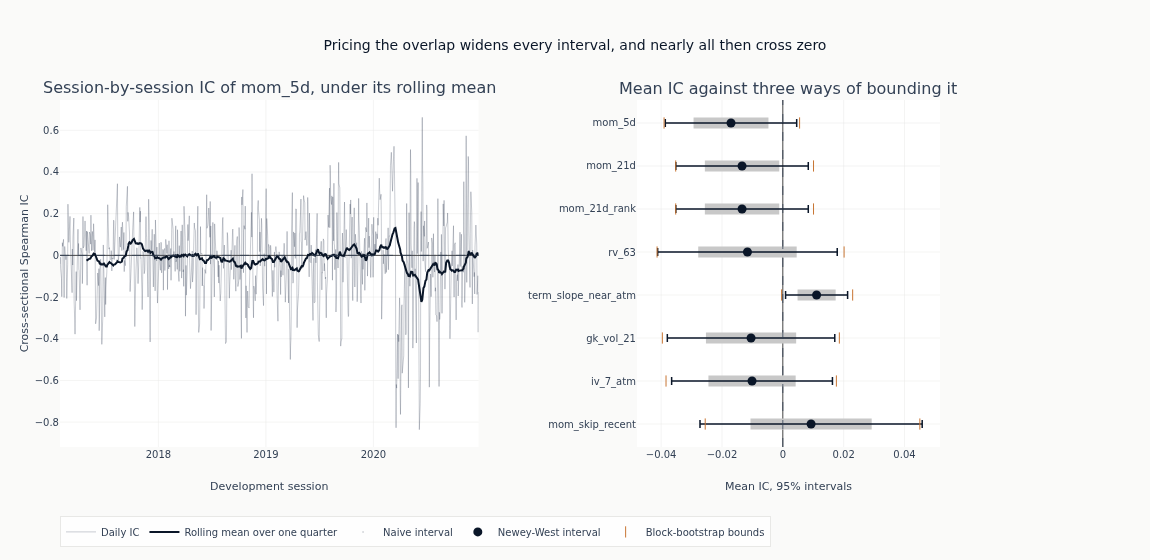

In [17]:
if leader:
    leader_series = (
        ic_timeseries[leader]
        .sort(DATE_COL)
        .with_columns(pl.col("ic").rolling_mean(IC_ROLLING_WINDOW).alias("rolling"))
    )
    interval_features = list(reversed(leaders))
    interval_means = [ic_uncertainty[name]["mean_ic"] for name in interval_features]
    fig = make_subplots(
        rows=1,
        cols=2,
        column_widths=[0.58, 0.42],
        subplot_titles=(
            f"Session-by-session IC of {leader}, under its rolling mean",
            "Mean IC against three ways of bounding it",
        ),
        horizontal_spacing=0.18,
    )
    _ = fig.add_trace(
        go.Scatter(
            x=leader_series[DATE_COL],
            y=leader_series["ic"],
            mode="lines",
            line={"color": COLORS["neutral"], "width": 0.6},
            opacity=0.45,
            name="Daily IC",
        ),
        row=1,
        col=1,
    )
    _ = fig.add_trace(
        go.Scatter(
            x=leader_series[DATE_COL],
            y=leader_series["rolling"],
            mode="lines",
            line={"color": COLORS["blue"], "width": 2},
            name="Rolling mean over one quarter",
        ),
        row=1,
        col=1,
    )
    _ = fig.add_hline(
        y=0, line={"color": COLORS["neutral"], "width": 0.8, "dash": "dash"}, row=1, col=1
    )
    _ = fig.add_trace(
        go.Scatter(
            x=interval_means,
            y=interval_features,
            mode="markers",
            marker={"color": COLORS["neutral"], "size": 1, "opacity": 0.0},
            error_x=interval_arms(interval_features, "ci_naive_lower", "ci_naive_upper")
            | {"color": GRAY_FILLS["tertiary"], "thickness": 11, "width": 0},
            name="Naive interval",
        ),
        row=1,
        col=2,
    )
    _ = fig.add_trace(
        go.Scatter(
            x=interval_means,
            y=interval_features,
            mode="markers",
            marker={"color": COLORS["blue"], "size": 9},
            error_x=interval_arms(interval_features, "ci_hac_lower", "ci_hac_upper")
            | {"color": COLORS["blue"], "thickness": 1.5},
            name="Newey-West interval",
        ),
        row=1,
        col=2,
    )
    _ = fig.add_trace(
        go.Scatter(
            x=[ic_uncertainty[name][bound] for name in interval_features for bound in BOOT_BOUNDS],
            y=[name for name in interval_features for _ in BOOT_BOUNDS],
            mode="markers",
            marker={"color": COLORS["copper"], "size": 8, "symbol": "line-ns-open"},
            name="Block-bootstrap bounds",
        ),
        row=1,
        col=2,
    )
    _ = fig.add_vline(
        x=0, line={"color": COLORS["neutral"], "width": 0.8, "dash": "dash"}, row=1, col=2
    )
    fig.update_layout(
        title="Pricing the overlap widens every interval, and nearly all then cross zero",
        height=560,
        width=1150,
        margin={"l": 60, "r": 210},
        legend={"orientation": "h", "y": -0.2},
    )
    fig.update_yaxes(title_text="Cross-sectional Spearman IC", row=1, col=1)
    fig.update_xaxes(title_text="Development session", row=1, col=1)
    fig.update_xaxes(title_text="Mean IC, 95% intervals", row=1, col=2)
    fig.show()

### Is it the same association in every window, or one episode?

An average over the whole development window can be produced by a feature that
worked throughout and by one that worked once and reversed. The walk-forward
folds are what separate them: each fold's validation window is a stretch of
sessions the model fitted on that fold never saw, and a feature that carries
information should point the same way in each of them.

**Sign consistency** is the share of folds whose mean information coefficient
has the same sign as the feature's own overall estimate. Measuring it against
the feature's own direction, rather than against positive, matters: a candidate
that is negative in every window is exactly as stable as one that is positive in
every window, and scoring the share of *positive* folds would put every
inversely predictive feature at zero and make it unpromotable however reliable
it was. `worst_fold_ic` follows the same rule - it is the fold furthest against
the feature's own direction, which for a negative feature is its algebraic
maximum rather than its minimum.

**The fold boundaries come from one place**, the same generator stage 04 called
to decide which of its rows are out of sample. That keeps a fold id meaning the
same thing on both sides of the join, and it means stability here is measured on
the validation windows only. Those cover the later part of the development
window, because a walk-forward scheme spends its early sessions training, so the
average in section 2 spans more sessions than these folds do and the two are not
expected to agree exactly.

With the two folds this case study declares, sign consistency can only be zero,
one half, or one. A quartile across two numbers is not worth reporting, so the
figure shows the fold means themselves, and the agreement bar printed with the
configuration is in effect a yes or no: both windows agree, or the feature does
not clear it. Two folds is a weak test of stability, and nothing below pretends
otherwise.

In [18]:
fold_boundaries = [(f["val_start"], f["val_end"]) for f in producer_folds]
for f in producer_folds:
    print(
        f"fold {f['fold']}: fitted {f['train_start']} to {f['train_end']}, "
        f"validated {f['val_start']} to {f['val_end']}"
    )
if max(end for _, end in fold_boundaries) >= holdout_start_date:
    msg = "A validation fold ends at or after the holdout boundary"
    raise ValueError(msg)

fold_stats = {}
for feat in ic_results:
    fold_ics = []
    ts = ic_timeseries[feat]
    for fold_start, fold_end in fold_boundaries:
        fold_ic = ts.filter((pl.col(DATE_COL) >= fold_start) & (pl.col(DATE_COL) <= fold_end))
        if len(fold_ic) >= 5:
            fold_ics.append(float(fold_ic["ic"].mean()))

    if fold_ics:
        direction = 1.0 if (ic_results[feat]["mean_ic"] or 0.0) >= 0 else -1.0
        signed = [ic * direction for ic in fold_ics]
        fold_stats[feat] = {
            "n_folds": len(fold_ics),
            "sign_consistency": sum(1 for s in signed if s > 0) / len(fold_ics),
            "worst_fold_ic": fold_ics[int(np.argmin(signed))],
            "best_fold_ic": fold_ics[int(np.argmax(signed))],
            "median_fold_ic": float(np.median(fold_ics)),
            "fold_ics": fold_ics,
        }

n_consistent = sum(
    1 for stats in fold_stats.values() if stats["sign_consistency"] >= SIGN_CONSISTENCY_MIN
)
print(
    f"Both validation windows agree with the feature's own direction for "
    f"{n_consistent} of the {len(fold_stats)} features scored across folds."
)

fold 0: fitted 2018-01-04 to 2019-12-18, validated 2020-01-06 to 2020-12-23
fold 1: fitted 2017-01-05 to 2018-12-19, validated 2019-01-07 to 2020-01-03
Both validation windows agree with the feature's own direction for 13 of the 36 features scored across folds.


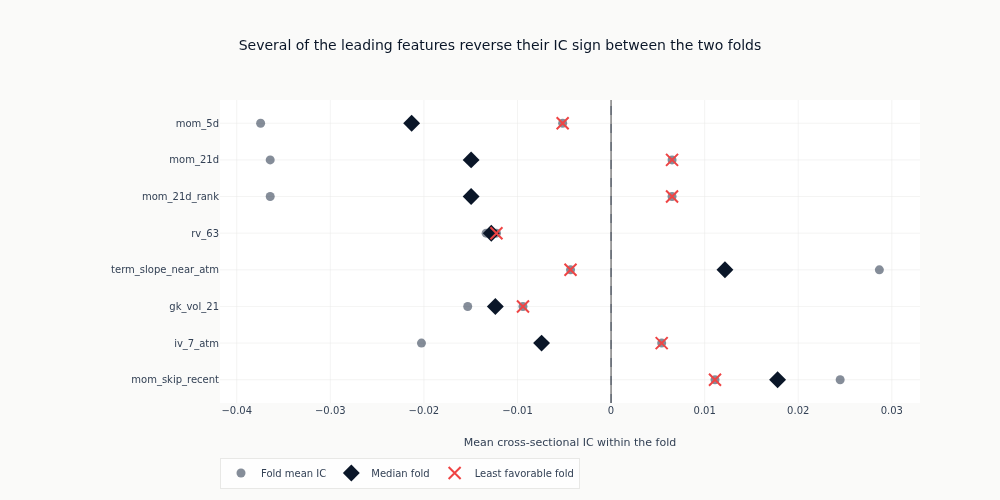

In [19]:
stability_features = [name for name in reversed(leaders) if name in fold_stats]
if stability_features:
    fig = go.Figure()
    _ = fig.add_trace(
        go.Scatter(
            x=[value for name in stability_features for value in fold_stats[name]["fold_ics"]],
            y=[name for name in stability_features for _ in fold_stats[name]["fold_ics"]],
            mode="markers",
            marker={"color": COLORS["neutral"], "size": 9, "opacity": 0.6},
            name="Fold mean IC",
        )
    )
    _ = fig.add_trace(
        go.Scatter(
            x=[fold_stats[name]["median_fold_ic"] for name in stability_features],
            y=stability_features,
            mode="markers",
            marker={"color": COLORS["blue"], "size": 13, "symbol": "diamond"},
            name="Median fold",
        )
    )
    _ = fig.add_trace(
        go.Scatter(
            x=[fold_stats[name]["worst_fold_ic"] for name in stability_features],
            y=stability_features,
            mode="markers",
            marker={
                "color": COLORS["negative"],
                "size": 12,
                "symbol": "x-thin",
                "line": {"width": 2, "color": COLORS["negative"]},
            },
            name="Least favorable fold",
        )
    )
    _ = fig.add_vline(x=0, line={"color": COLORS["neutral"], "width": 0.8, "dash": "dash"})
    fig.update_layout(
        title="Several of the leading features reverse their IC sign between the two folds",
        xaxis_title="Mean cross-sectional IC within the fold",
        height=500,
        width=1000,
        margin={"l": 220},
        legend={"orientation": "h", "y": -0.18},
    )
    fig.show()

## 3. What did the search cost?

**The searched set comes first.** A p-value answers "how surprising would this
be if the feature carried nothing", and that question is only interpretable
against the number of features asked it: test enough candidates at a fixed level
and some will look significant with nothing behind any of them, purely from the
count. So the set is stated before the adjustment is applied. It is every column
in the register above - the declared families and the conditional-volatility
estimators - restricted to those that cleared section 1. Generation is blind to
the label; nothing was added to the register after seeing a correlation. Only
the primary label is screened, and the other declared label variants are not
tested, so they do not enter the count.

**The adjustment.** The Benjamini-Hochberg procedure sorts the p-values and
rejects as many of the smallest as it can while holding the expected share of
false ones among those it rejects to the declared false-discovery rate. That is
a weaker guarantee than "no false positives at all" and a much more useful one:
it scales with the size of the search instead of collapsing to nothing, as a
Bonferroni-style bound would on a set this size.

Three counts are printed, and the distance between them is the point of the
section: how many features look significant if each session is treated as an
independent observation, how many still do once the label overlap is priced in,
and how many survive being one of a whole set tested at once.

**Few or no survivors is a reading of this case study, not a failure of the
screen.** Implied volatility is a forecast of a name's coming volatility, and
nothing about it says which direction that name will move; there is no strong
reason for a level of implied volatility to rank next week's returns on its own.
Whether these features contribute in combination is a different question, and
one this notebook does not test.

In [20]:
feature_names = list(ic_results.keys())
p_values = [ic_results[f]["p_value"] for f in feature_names]

fdr_result = benjamini_hochberg_fdr(p_values, alpha=FDR_ALPHA, return_details=True)

eval_summary = pl.DataFrame(
    {
        "feature": feature_names,
        "source": ["temporal" if f in temporal_cols else "financial" for f in feature_names],
        "ic_mean": [ic_results[f]["mean_ic"] for f in feature_names],
        "hac_se": [ic_results[f]["hac_se"] for f in feature_names],
        "hac_t": [ic_results[f]["t_stat"] for f in feature_names],
        "hac_p": p_values,
        "fdr_p": [float(p) for p in fdr_result["adjusted_p_values"]],
        "fdr_sig": [bool(r) for r in fdr_result["rejected"]],
        "naive_t": [ic_results[f]["naive_t_stat"] for f in feature_names],
    },
    schema_overrides={
        "ic_mean": pl.Float64,
        "hac_se": pl.Float64,
        "hac_t": pl.Float64,
        "hac_p": pl.Float64,
        "fdr_p": pl.Float64,
        "fdr_sig": pl.Boolean,
        "naive_t": pl.Float64,
    },
).sort(pl.col("ic_mean").cast(pl.Float64, strict=False).abs(), descending=True)

# The unadjusted p-value has to be rebuilt from the unadjusted t-statistic: the
# estimator returns the Newey-West p-value and both t-statistics, so the naive
# tier of the comparison below is derived here rather than read off.
naive_p_values = [
    float(2 * student_t.sf(abs(ic_results[f]["naive_t_stat"]), df=ic_results[f]["n_periods"] - 1))
    for f in feature_names
]
n_searched = len(feature_names)
expected_false_positives = FDR_ALPHA * n_searched

n_significant_naive = sum(1 for p in naive_p_values if p < FDR_ALPHA)
n_significant_hac = sum(1 for p in p_values if p < FDR_ALPHA)
n_significant_fdr = int(fdr_result["n_rejected"])


def inflation(naive_count: int, adjusted_count: int) -> str:
    """How much the unadjusted count overstates the adjusted one.

    Undefined when the adjustment rejects nothing: substituting one for a zero
    denominator reports a finite ratio where none exists, and the reader cannot
    tell the substitution from a measurement.
    """
    if adjusted_count == 0:
        return "undefined (the adjustment rejected nothing)"
    return f"{naive_count / adjusted_count:.2f}x"


median_hac_se = float(np.median([ic_results[f]["hac_se"] for f in feature_names] or [float("nan")]))
largest_abs_ic = max((abs(ic_results[f]["mean_ic"]) for f in feature_names), default=float("nan"))

print(f"Searched set: {n_searched} features with a computable IC on {label_col}.")
print(
    f"Testing that many at {FDR_ALPHA:.0%} would produce "
    f"{expected_false_positives:.1f} apparent discoveries with nothing behind them."
)
print(f"  Significant treating sessions as independent: {n_significant_naive}")
print(f"  Significant after Newey-West:                 {n_significant_hac}")
print(f"  Significant after Benjamini-Hochberg:         {n_significant_fdr}")
print(
    f"The independent count overstates the Newey-West one by "
    f"{inflation(n_significant_naive, n_significant_hac)}, and the "
    f"Benjamini-Hochberg one by {inflation(n_significant_naive, n_significant_fdr)}."
)
print(f"\nLargest absolute mean IC in the set: {largest_abs_ic:.4f}")
print(
    f"Median Newey-West standard error of a mean IC: {median_hac_se:.4f}. The "
    f"effect-size floor the second promotion arm uses, {IC_THRESHOLD}, is read against "
    f"that: it sits below the typical standard error, so clearing it is a weaker "
    f"requirement than being distinguishable from zero."
)

Searched set: 36 features with a computable IC on fwd_ret_5d.
Testing that many at 5% would produce 1.8 apparent discoveries with nothing behind them.
  Significant treating sessions as independent: 5
  Significant after Newey-West:                 1
  Significant after Benjamini-Hochberg:         0
The independent count overstates the Newey-West one by 5.00x, and the Benjamini-Hochberg one by undefined (the adjustment rejected nothing).

Largest absolute mean IC in the set: 0.0170
Median Newey-West standard error of a mean IC: 0.0108. The effect-size floor the second promotion arm uses, 0.005, is read against that: it sits below the typical standard error, so clearing it is a weaker requirement than being distinguishable from zero.


**What the two corrections cost.** Treating each session as an independent
observation makes a handful of these features look significant. Pricing in the
five-session overlap removes all but one, because a feature whose correlation was
carried by one stretch of sessions has far fewer effectively independent
observations behind it than the session count suggests. Applying the
false-discovery adjustment across the whole searched set removes the one that was
left, so nothing here clears the adjustment.

The interval figure above shows the same thing one feature at a time, and it also
shows why three bounds are drawn rather than one. The near-term term-structure
slope is the single candidate whose Newey-West interval still excludes zero - and
its block-bootstrap bounds, which assume neither a variance formula nor a
distribution, reach zero anyway. Two corrections that disagree about the same
average is the reader's signal to treat it as undecided rather than as a finding.

The largest absolute mean information coefficient in the panel is printed above,
and even it has a Newey-West interval that includes zero. That is the honest
reading of a univariate screen on weekly equity returns, and it is also why the
effect-size floor the exploration arm uses in section 6 has to be read as a floor
on effect size rather than as evidence of one.

### Which features rank highest, and what the adjustment does to them

The left panel ranks the leading features by absolute mean information
coefficient, coloured by whether each cleared the false-discovery adjustment.
The right panel plots the Newey-West t-statistic against its unadjusted twin for
every feature in the searched set. A point on the dashed diagonal is a feature
whose sessions carried independent information; a point pulled toward zero off
it is one whose apparent significance came from the overlap between consecutive
five-session returns rather than from the size of its correlation. Bars run
horizontally because at this many feature names a rotated vertical axis is not
legible.

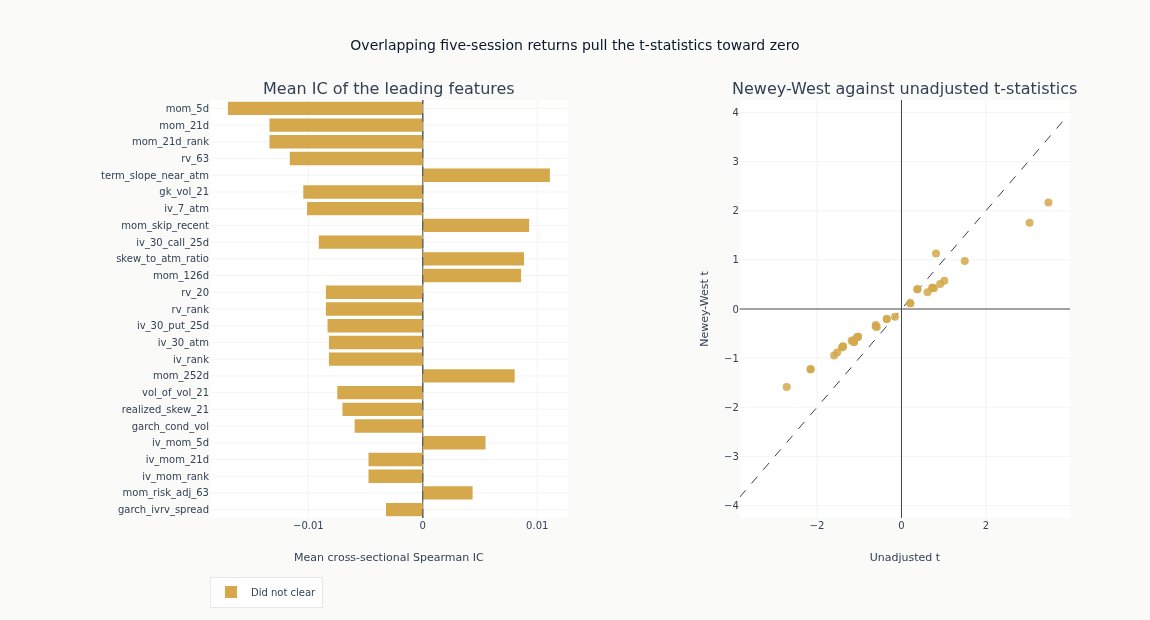

In [21]:
RANKED_FEATURES = 25
top = eval_summary.head(min(RANKED_FEATURES, len(eval_summary))).reverse()

fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.52, 0.48],
    subplot_titles=[
        "Mean IC of the leading features",
        "Newey-West against unadjusted t-statistics",
    ],
    horizontal_spacing=0.2,
)
for cleared, color, name in (
    (True, COLORS["blue"], "Cleared BH-FDR"),
    (False, COLORS["amber"], "Did not clear"),
):
    arm = top.filter(pl.col("fdr_sig").fill_null(False) == cleared)
    if not len(arm):
        continue
    _ = fig.add_trace(
        go.Bar(
            x=arm["ic_mean"].to_list(),
            y=arm["feature"].to_list(),
            orientation="h",
            marker_color=color,
            name=name,
        ),
        row=1,
        col=1,
    )
_ = fig.add_vline(
    x=0, line={"color": COLORS["neutral"], "width": 0.8, "dash": "dash"}, row=1, col=1
)

max_t = (
    max(
        eval_summary["naive_t"].cast(pl.Float64, strict=False).abs().max() or 1.0,
        eval_summary["hac_t"].cast(pl.Float64, strict=False).abs().max() or 1.0,
    )
    * 1.1
)
_ = fig.add_trace(
    go.Scatter(
        x=[-max_t, max_t],
        y=[-max_t, max_t],
        mode="lines",
        line={"dash": "dash", "color": COLORS["neutral"], "width": 1},
        showlegend=False,
    ),
    row=1,
    col=2,
)
for cleared, color, name in (
    (True, COLORS["blue"], "Cleared BH-FDR"),
    (False, COLORS["amber"], "Did not clear"),
):
    arm = eval_summary.filter(pl.col("fdr_sig").fill_null(False) == cleared)
    if not len(arm):
        continue
    _ = fig.add_trace(
        go.Scatter(
            x=arm["naive_t"].to_list(),
            y=arm["hac_t"].to_list(),
            mode="markers",
            marker={"color": color, "size": 8, "opacity": 0.85},
            text=arm["feature"].to_list(),
            name=name,
            showlegend=False,
        ),
        row=1,
        col=2,
    )
fig.update_layout(
    title="Overlapping five-session returns pull the t-statistics toward zero",
    height=620,
    width=1150,
    margin={"l": 210},
    legend={"orientation": "h", "y": -0.14},
)
# Two traces split the ranking by outcome, so the y order has to be restated or the
# categories fall in trace order and the ranking the panel exists to show is lost.
fig.update_yaxes(categoryorder="array", categoryarray=top["feature"].to_list(), row=1, col=1)
fig.update_xaxes(title_text="Mean cross-sectional Spearman IC", row=1, col=1)
fig.update_xaxes(title_text="Unadjusted t", row=1, col=2)
fig.update_yaxes(title_text="Newey-West t", row=1, col=2)
fig.show()

## 4. Is the relationship the shape a ranking can use?

A correlation says the ordering is right on average. It does not say the
relationship is smooth. The strategy this case study builds acts by sorting
names and holding the ends, so what it needs is for the mean return to change
steadily from the bottom group to the top - not for one extreme group to carry
everything while the middle is flat. **Monotonicity** here is the rank
correlation between a quantile's position and its mean return: one when the
groups line up perfectly in order, zero when their order says nothing, negative
when they run backwards.

**The groups are formed inside each session, not over the pooled sample.** On
every session the names quoted that session are sorted on the feature and split
into five equal groups, and the returns are averaged within group across
sessions. Doing it the other way - one set of cut points over the whole
development window - would let a session in which the whole market's implied
volatility was high place all its names in the top group, so the profile would
be mixing "high for this name relative to its peers today" with "a high-
volatility period", while the correlation it sits beside is purely
within-session. The two diagnostics would then be answering different questions
while appearing to corroborate each other.

In [22]:
top_features_for_shape = eval_summary.filter(pl.col("fdr_sig").fill_null(False))[
    "feature"
].to_list()[:15]
if not top_features_for_shape:
    top_features_for_shape = eval_summary.head(10)["feature"].to_list()

monotonicity_scores = {}
quantile_spreads = {}

for feat in top_features_for_shape:
    valid = eval_panel.select([DATE_COL, feat, label_col]).drop_nulls()
    if len(valid) < N_QUANTILES * MIN_CROSS_SECTION:
        continue

    binned = quantize_factor(
        valid, n_quantiles=N_QUANTILES, factor_col=feat, date_col=DATE_COL
    ).drop_nulls(subset=["quantile"])
    q_means = binned.group_by("quantile").agg(pl.col(label_col).mean()).sort("quantile")
    means = q_means[label_col].to_list()
    quantile_spreads[feat] = {"q_means": means, "spread": means[-1] - means[0]}
    monotonicity_scores[feat] = monotonicity_score(
        dict(zip(q_means["quantile"].to_list(), means, strict=True))
    )

print(f"Quantile profile built for {len(quantile_spreads)} features.")

Quantile profile built for 10 features.


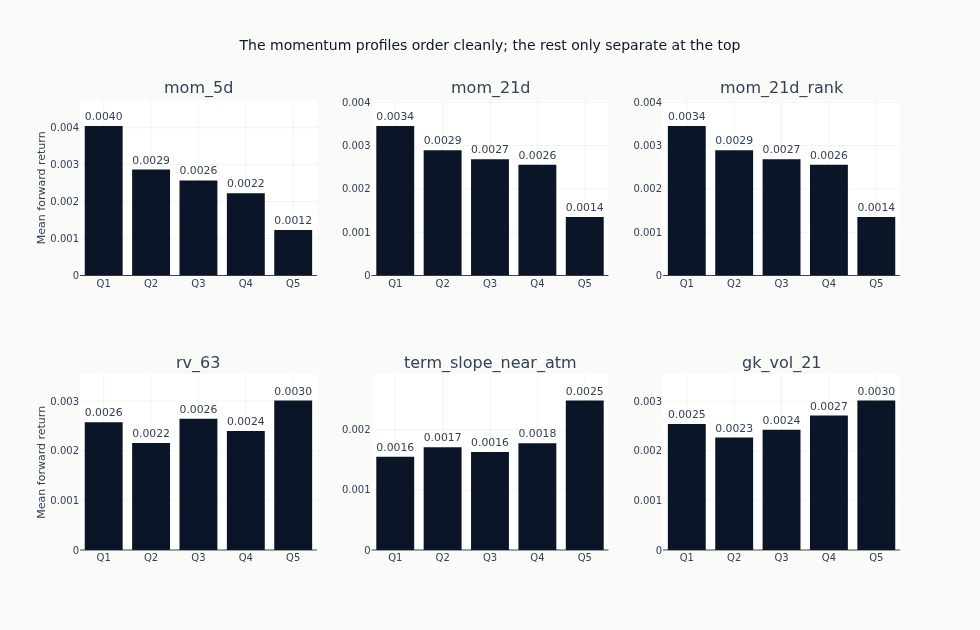

Top group minus bottom group, and how ordered the five groups are:
  mom_5d                       spread=-0.00281  monotonicity=-1.00
  mom_21d                      spread=-0.00210  monotonicity=-1.00
  mom_21d_rank                 spread=-0.00210  monotonicity=-1.00
  rv_63                        spread=+0.00044  monotonicity=+0.50
  term_slope_near_atm          spread=+0.00094  monotonicity=+0.90
  gk_vol_21                    spread=+0.00047  monotonicity=+0.70


In [23]:
if quantile_spreads:
    n_show = min(6, len(quantile_spreads))
    feats_to_show = list(quantile_spreads.keys())[:n_show]
    n_rows_fig = (n_show + 2) // 3
    fig = make_subplots(
        rows=n_rows_fig,
        cols=3,
        subplot_titles=feats_to_show,
        vertical_spacing=0.22,
    )
    for idx, feat in enumerate(feats_to_show):
        r, c = divmod(idx, 3)
        q_means = quantile_spreads[feat]["q_means"]
        _ = fig.add_trace(
            go.Bar(
                x=[f"Q{i + 1}" for i in range(len(q_means))],
                y=q_means,
                marker_color=COLORS["blue"],
                showlegend=False,
                text=[f"{m:.4f}" for m in q_means],
                textposition="outside",
            ),
            row=r + 1,
            col=c + 1,
        )
    fig.update_layout(
        title="The momentum profiles order cleanly; the rest only separate at the top",
        height=270 * n_rows_fig + 90,
        width=980,
    )
    fig.update_yaxes(title_text="Mean forward return", col=1)
    fig.show()
    print("Top group minus bottom group, and how ordered the five groups are:")
    for feat in feats_to_show:
        print(
            f"  {feat:28s} spread={quantile_spreads[feat]['spread']:+.5f}"
            f"  monotonicity={monotonicity_scores[feat]:+.2f}"
        )

## 5. Which candidates are the same evidence twice?

A few dozen features built from one option surface and one price series are not
a few dozen independent pieces of evidence. Two columns whose rank correlation
is high enough carry the same ordering under two names: counting both inflates the
apparent breadth of the search, and a linear model given both cannot separate
their contributions. This section asks which pairs those are, groups them, and
picks the one member of each group that stands for the rest. Standing for a
group does not promote a feature - it still has to earn its own decision in the
triage below - and nothing here removes a column from the matrix the models
train on.

Correlations are computed on a sample of development sessions rather than on
every row, which is enough to rank the pairs and keeps the calculation to a size
a reader can re-run.

In [24]:
sample_step = max(1, n_dates // 200)
sample_dates = eval_panel[DATE_COL].unique().sort().to_list()[::sample_step]
corr_data = (
    eval_panel.filter(pl.col(DATE_COL).is_in(sample_dates)).select(evaluable_features).to_pandas()
)
corr_matrix = corr_data.corr(method="spearman")

high_corr_pairs = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if abs(corr_matrix.iloc[i, j]) > REDUNDANCY_CUT:
            high_corr_pairs.append((cols[i], cols[j], float(corr_matrix.iloc[i, j])))

print(f"Pairs whose |rank correlation| exceeds {REDUNDANCY_CUT}: {len(high_corr_pairs)}")

Pairs whose |rank correlation| exceeds 0.7: 41


### One feature stands for each group

Redundancy is transitive: if A repeats B and B repeats C, the three are one
group even when A and C are not directly above the cut. So the pairs are joined
into connected groups first, and one member of each is then chosen by the
criterion Chapter 8 sets for deduplication - the largest median information
coefficient across the folds, and among those the smallest spread between folds.
The order matters: size first, because a feature that carries nothing reliably
is not worth keeping over one that carries something less reliably.

A feature with no fold statistics cannot be compared on that criterion, so it is
ranked last within its group rather than dropped from it.

In [25]:
fdr_sig_set = set(eval_summary.filter(pl.col("fdr_sig").fill_null(False))["feature"].to_list())
group_of = {feature: feature for feature in evaluable_features}


def group_root(feature: str) -> str:
    """The label of the connected group a feature currently sits in."""
    while group_of[feature] != feature:
        group_of[feature] = group_of[group_of[feature]]
        feature = group_of[feature]
    return feature


def selection_key(feature: str) -> tuple[float, float]:
    """Rank within a group: largest median fold IC first, then tightest spread."""
    stats = fold_stats.get(feature)
    if not stats:
        return (-1.0, 0.0)
    return (abs(stats["median_fold_ic"]), -float(np.std(stats["fold_ics"], ddof=0)))


for left, right, _ in high_corr_pairs:
    left_root, right_root = group_root(left), group_root(right)
    if left_root != right_root:
        group_of[left_root] = right_root

groups = {}
for feature in evaluable_features:
    groups.setdefault(group_root(feature), []).append(feature)

represented_by = {}
for members in groups.values():
    chosen = max(members, key=selection_key)
    for member in members:
        represented_by[member] = chosen

redundant_groups = {name: members for name, members in groups.items() if len(members) > 1}
print(
    f"The {len(evaluable_features)} screened features reduce to {len(groups)} distinct "
    f"orderings, of which {len(redundant_groups)} hold more than one feature."
)

representative_rows = []
for members in redundant_groups.values():
    chosen = represented_by[members[0]]
    stats = fold_stats.get(chosen, {})
    representative_rows.append(
        {
            "stands for": chosen,
            "members": len(members),
            "median fold IC": round(stats.get("median_fold_ic", float("nan")), 4),
            "spread across folds": round(float(np.std(stats.get("fold_ics", [0.0]), ddof=0)), 4),
            "dropped for it": ", ".join(sorted(m for m in members if m != chosen)),
        }
    )

representatives = (
    pl.DataFrame(representative_rows).sort("members", descending=True)
    if representative_rows
    else pl.DataFrame(schema={"stands for": pl.String, "members": pl.Int64})
)
representatives

The 36 screened features reduce to 18 distinct orderings, of which 7 hold more than one feature.


stands for,members,median fold IC,spread across folds,dropped for it
str,i64,f64,f64,str
"""rv_63""",10,-0.0128,0.0006,"""garch_cond_vol, gk_vol_21, iv_…"
"""mom_21d""",3,-0.015,0.0215,"""mom_21d_rank, realized_skew_21"""
"""mom_63d""",3,-0.0056,0.0024,"""mom_63d_rank, mom_risk_adj_63"""
"""skew_to_atm_ratio""",3,0.0093,0.0091,"""skew_rank, skew_rr_30_25d"""
"""d_iv_30_atm""",2,0.0028,0.0036,"""d_iv_rank"""
"""ivrv_spread""",2,-0.0044,0.0072,"""vrp_rank"""
"""mom_skip_recent""",2,0.0178,0.0067,"""mom_252d"""


### The strongest redundant pairs

Ranked pairs rather than the full matrix: the question is which two candidates
are the same evidence entered twice, and a heatmap over this many features
answers it only if the reader can still read the tick labels. Each bar names both
members with the family each belongs to, and marks with an asterisk whichever of
the two stands for its group. A pair inside one family and a pair spanning two
are then distinguishable, and the second kind is what a family-by-family
selection would miss.

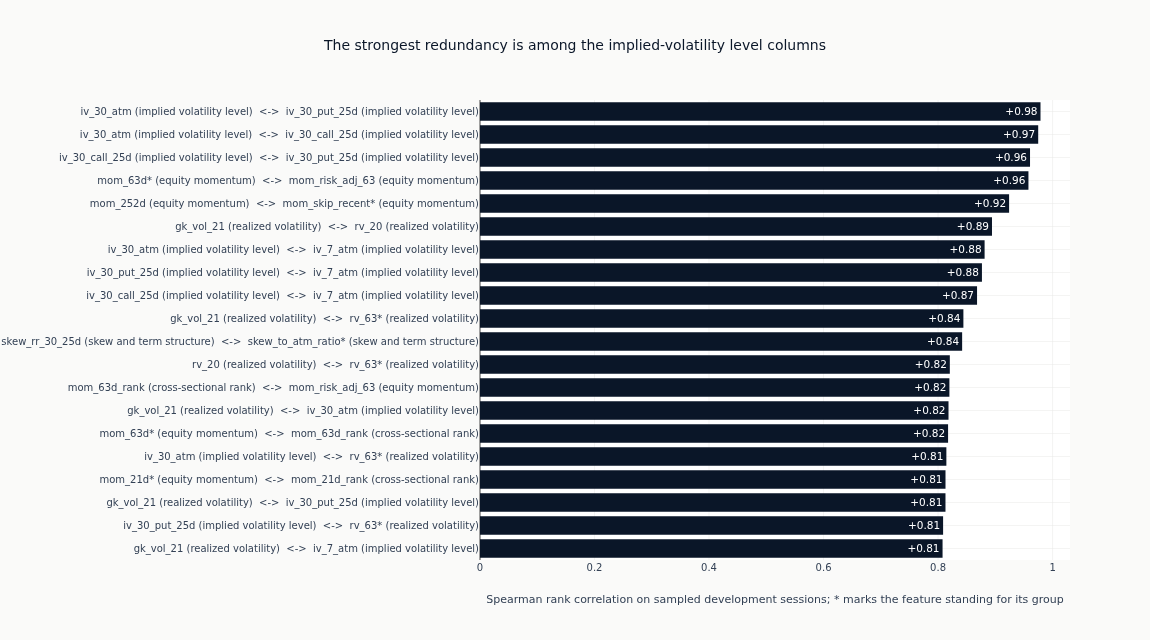

Of the 20 strongest pairs, 8 span two families


In [26]:
RANKED_PAIRS = 20
if high_corr_pairs:
    ranked = sorted(high_corr_pairs, key=lambda pair: abs(pair[2]), reverse=True)[:RANKED_PAIRS]

    def pair_member(name: str) -> str:
        """Name a member with its family, starred when it stands for its group."""
        star = "*" if represented_by.get(name) == name else ""
        return f"{name}{star} ({families.get(name, 'unassigned')})"

    pair_labels = [f"{pair_member(left)}  <->  {pair_member(right)}" for left, right, _ in ranked]
    pair_values = [value for _, _, value in ranked]
    cross_family = sum(families.get(left) != families.get(right) for left, right, _ in ranked)
    fig = go.Figure(
        go.Bar(
            x=list(reversed(pair_values)),
            y=list(reversed(pair_labels)),
            orientation="h",
            marker_color=[
                COLORS["blue"] if value > 0 else COLORS["copper"] for value in reversed(pair_values)
            ],
            text=[f"{value:+.2f}" for value in reversed(pair_values)],
            textposition="inside",
        )
    )
    fig.update_layout(
        title="The strongest redundancy is among the implied-volatility level columns",
        xaxis_title=(
            "Spearman rank correlation on sampled development sessions; "
            "* marks the feature standing for its group"
        ),
        height=640,
        width=1150,
        margin={"l": 480},
        showlegend=False,
    )
    fig.show()
    print(f"Of the {len(ranked)} strongest pairs, {cross_family} span two families")

### How the families compare

The register groups the candidates by what they are built from and what they are
supposed to capture, so the natural next question is whether any of those groups
does better than the others. The bars are the average absolute mean information
coefficient within each family, with the number of features behind each average
on the bar - an average over one feature is not evidence about a family.

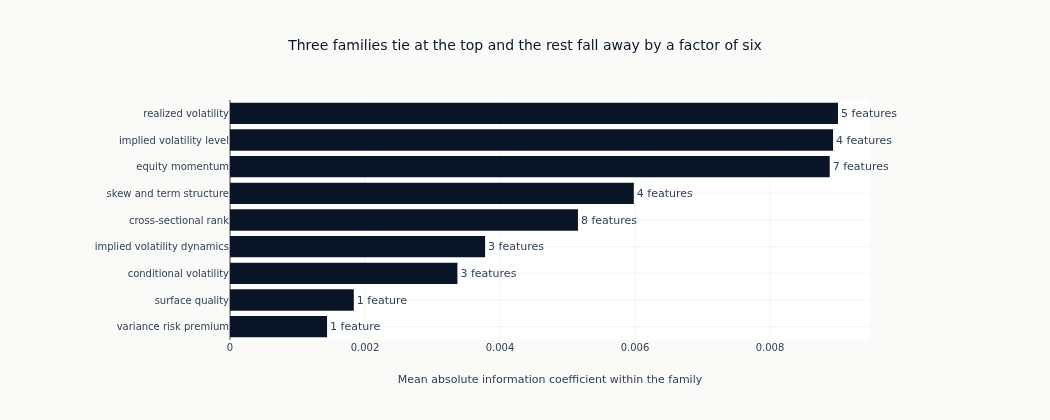

In [27]:
family_rows = []
for fam in sorted(set(families.values())):
    ics = [
        ic_results[f]["mean_ic"]
        for f in ic_results
        if families.get(f) == fam and ic_results[f]["mean_ic"] is not None
    ]
    if not ics:
        continue
    family_rows.append(
        {
            "family": fam,
            "n": len(ics),
            "avg_abs_ic": float(np.mean([abs(ic) for ic in ics])),
            "n_fdr_sig": sum(1 for f in ic_results if families.get(f) == fam and f in fdr_sig_set),
        }
    )
if family_rows:
    fam_df = pl.DataFrame(family_rows).sort("avg_abs_ic")
    fig = go.Figure(
        go.Bar(
            x=fam_df["avg_abs_ic"].to_list(),
            y=fam_df["family"].to_list(),
            orientation="h",
            marker_color=COLORS["blue"],
            text=[f"{n} feature{'s' if n != 1 else ''}" for n in fam_df["n"].to_list()],
            textposition="outside",
            cliponaxis=False,
        )
    )
    fig.update_layout(
        title="Three families tie at the top and the rest fall away by a factor of six",
        xaxis_title="Mean absolute information coefficient within the family",
        height=420,
        width=1050,
        margin={"l": 230, "r": 180},
        showlegend=False,
    )
    fig.show()

## 6. One decision per feature

The book's Table 7.2 rule. Every feature gets one of three labels, and the
evidence behind it is written beside it so the decision can be re-read rather
than taken on trust.

| Decision | Criteria | Arm |
|----------|----------|-----|
| **PROCEED** | cleared the false-discovery adjustment | confirmation |
| **PROCEED** | both folds share the feature's own sign, and its mean absolute information coefficient clears the effect-size floor | exploration |
| **STOP** | failed section 1 on coverage or on staleness | - |
| **REVISE** | everything else, including columns constant across names | - |

**Two arms, and the difference between them is what the reader has to carry
forward.** The first is confirmatory: the feature cleared an adjustment made
over the whole declared search. The second is exploratory in the sense of book
§7.4 - it promotes on fold agreement and effect size rather than on
significance, so that a screen run on a short history does not come back empty,
and a feature promoted through it has been confirmed by nothing. Because the
rule is a disjunction, the promoted count can exceed the count that cleared the
adjustment. The ledger's `note` column records which arm fired, and reading a
promotion without it is reading two different claims as one.

`monotonicity` is written to the ledger as evidence and is not read by the rule.

In [28]:
triage = {}
for feat in all_feature_cols:
    if not correctness[feat]:
        triage[feat] = ("STOP", "correctness_fail")
        continue

    if feat in date_level_features:
        triage[feat] = ("REVISE", "date_level_feature")
        continue

    if feat not in ic_results:
        triage[feat] = ("REVISE", "insufficient_data")
        continue

    is_fdr_sig = feat in fdr_sig_set
    sign_con = fold_stats.get(feat, {}).get("sign_consistency", 0)
    abs_ic = abs(ic_results[feat]["mean_ic"])

    if is_fdr_sig:
        triage[feat] = ("PROCEED", "fdr_significant")
    elif sign_con >= SIGN_CONSISTENCY_MIN and abs_ic >= IC_THRESHOLD:
        triage[feat] = ("PROCEED", "stable_and_above_threshold")
    else:
        triage[feat] = ("REVISE", "not_significant_standalone")

In [29]:
ledger_rows = []
for feat in all_feature_cols:
    decision, note = triage[feat]
    row = {
        "feature": feat,
        "family": families[feat],
        "source": "temporal" if feat in temporal_cols else "financial",
        "ic_mean": ic_results.get(feat, {}).get("mean_ic"),
        "hac_t": ic_results.get(feat, {}).get("t_stat"),
        "hac_p": ic_results.get(feat, {}).get("p_value"),
        "fdr_p": None,
        "fdr_sig": False,
        "sign_consistency": fold_stats.get(feat, {}).get("sign_consistency"),
        "worst_fold_ic": fold_stats.get(feat, {}).get("worst_fold_ic"),
        "monotonicity": monotonicity_scores.get(feat),
        "coverage": coverage[feat],
        "staleness": staleness[feat],
        "decision": decision,
        "note": note,
    }
    match = eval_summary.filter(pl.col("feature") == feat)
    if len(match) > 0:
        row["fdr_p"] = float(match["fdr_p"][0])
        row["fdr_sig"] = bool(match["fdr_sig"][0])
    ledger_rows.append(row)

triage_ledger = pl.DataFrame(ledger_rows).sort(["decision", "feature"])
triage_ledger.write_parquet(EVAL_DIR / "triage_ledger.parquet")
print(f"Triage ledger written to {display_path(EVAL_DIR / 'triage_ledger.parquet')}")

ic_ts_all = pl.concat(
    [ts.with_columns(pl.lit(feat).alias("feature")) for feat, ts in ic_timeseries.items()]
)
ic_ts_all.write_parquet(EVAL_DIR / "ic_timeseries.parquet")
print(
    f"Per-session information coefficients written to "
    f"{display_path(EVAL_DIR / 'ic_timeseries.parquet')} ({len(ic_ts_all):,} rows)"
)

Triage ledger written to case_studies/sp500_equity_option_analytics/evaluation/triage_ledger.parquet
Per-session information coefficients written to case_studies/sp500_equity_option_analytics/evaluation/ic_timeseries.parquet (33,108 rows)


In [30]:
proceed_features = sorted(f for f, (d, _) in triage.items() if d == "PROCEED")
revise_features = [f for f, (d, _) in triage.items() if d == "REVISE"]
stop_features = [f for f, (d, _) in triage.items() if d == "STOP"]

print(
    f"PROCEED {len(proceed_features)}, REVISE {len(revise_features)}, "
    f"STOP {len(stop_features)}, out of {len(all_feature_cols)} candidates."
)
triage_ledger.group_by(["decision", "note"]).len().sort("len", descending=True)

PROCEED 13, REVISE 23, STOP 12, out of 48 candidates.


decision,note,len
str,str,u32
"""REVISE""","""not_significant_standalone""",23
"""PROCEED""","""stable_and_above_threshold""",13
"""STOP""","""correctness_fail""",12


### What the search kept, stage by stage

What was searched, what came through each stage, and what each arm of the
promotion rule contributed. Drawn rather than printed, because the size of the
drop between consecutive bars is what a reader is meant to weigh, and separating
the two arms is what shows whether a rule written as a disjunction behaves like
one.

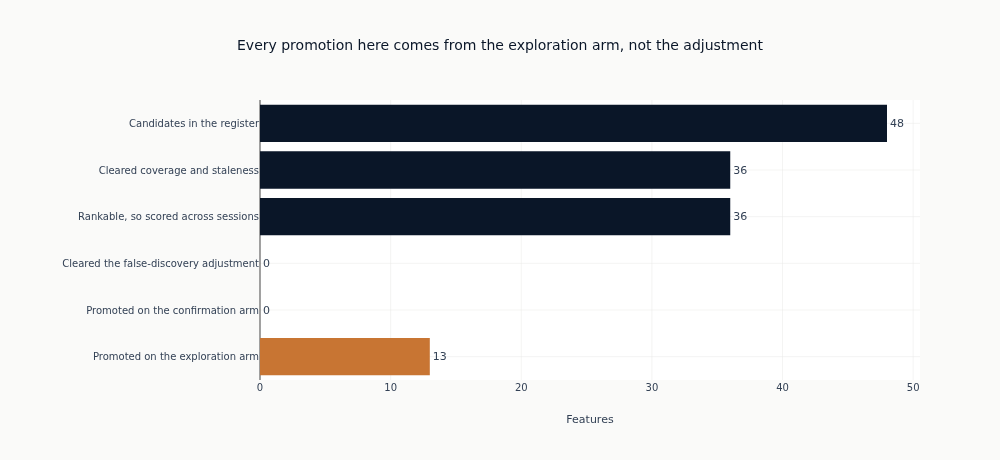

Promoted features, with the arm that promoted each:
  gk_vol_21                    IC=-0.0104  Newey-West t=-0.76  [realized volatility, stable_and_above_threshold]
  iv_30_atm                    IC=-0.0082  Newey-West t=-0.56  [implied volatility level, stable_and_above_threshold]
  iv_30_call_25d               IC=-0.0091  Newey-West t=-0.65  [implied volatility level, stable_and_above_threshold]
  iv_30_put_25d                IC=-0.0083  Newey-West t=-0.58  [implied volatility level, stable_and_above_threshold]
  iv_rank                      IC=-0.0082  Newey-West t=-0.56  [cross-sectional rank, stable_and_above_threshold]
  mom_252d                     IC=+0.0080  Newey-West t=+0.42  [equity momentum, stable_and_above_threshold]
  mom_5d                       IC=-0.0170  Newey-West t=-1.59  [equity momentum, stable_and_above_threshold]
  mom_skip_recent              IC=+0.0093  Newey-West t=+0.51  [equity momentum, stable_and_above_threshold]
  rv_20                        IC=-0.008

In [31]:
arm_counts = {
    note: len([f for f, (d, n) in triage.items() if d == "PROCEED" and n == note])
    for note in ("fdr_significant", "stable_and_above_threshold")
}
funnel_stages = [
    ("Candidates in the register", len(all_feature_cols), COLORS["blue"]),
    ("Cleared coverage and staleness", n_pass, COLORS["blue"]),
    ("Rankable, so scored across sessions", n_searched, COLORS["blue"]),
    ("Cleared the false-discovery adjustment", n_significant_fdr, COLORS["blue"]),
    ("Promoted on the confirmation arm", arm_counts["fdr_significant"], COLORS["copper"]),
    (
        "Promoted on the exploration arm",
        arm_counts["stable_and_above_threshold"],
        COLORS["copper"],
    ),
]
fig = go.Figure(
    go.Bar(
        x=[count for _, count, _ in funnel_stages],
        y=[stage for stage, _, _ in funnel_stages],
        orientation="h",
        marker_color=[color for _, _, color in funnel_stages],
        text=[str(count) for _, count, _ in funnel_stages],
        textposition="outside",
    )
)
fig.update_layout(
    title="Every promotion here comes from the exploration arm, not the adjustment",
    xaxis_title="Features",
    height=460,
    width=1000,
    margin={"l": 260, "r": 80},
    showlegend=False,
)
fig.update_yaxes(autorange="reversed")
fig.show()
print("Promoted features, with the arm that promoted each:")
for f in proceed_features:
    print(
        f"  {f:28s} IC={ic_results[f]['mean_ic']:+.4f}"
        f"  Newey-West t={ic_results[f]['t_stat']:+.2f}"
        f"  [{families[f]}, {triage[f][1]}]"
    )

**What this screen decided, and on what.** The counts above are the whole output
of the notebook: one decision per feature, with the `note` column recording
which arm produced it. The confirmation arm promoted nothing on this panel, and
that is a property of the question rather than a fault in the screen - implied
volatility is a forecast of how much a name will move, not of which way, so
there is no strong prior reason for its level to rank next week's returns on its
own. The exploration arm is what keeps a fold-consistent set with a
non-negligible effect size on the table for the multivariate models in Ch11, and
the ledger says which features arrived that way.

**PROCEED means "not yet ruled out".** Everything promoted here came through the
exploration arm, and with two folds that arm asks only that both windows point
the same way, which one coin flip in two would satisfy. It screens against an
association produced by a single episode, and it does nothing more. Reading the
promoted list without the `note` column reads two very different claims as one.

This notebook does not pronounce on the case study. A univariate screen is
necessary and not sufficient, and whether any of these features is tradable is
settled by a backtest several stages later.

## Key takeaways

### The method

1. **Hold the test period back first, and account for what the label reaches.**
   Dropping sessions dated inside the holdout is not enough when a label looks
   forward: the last few development decisions have outcomes that resolve on the
   other side, so they go too. The width of that gap is the label's horizon,
   counted on the trading calendar the data is on.
2. **Screen the definition before the association.** Coverage and staleness are
   properties a feature has whether or not it predicts anything, and a column
   that mostly repeats itself can produce a correlation that is entirely the
   carry-forward.
3. **State the searched set before the p-value.** A significance claim is only
   interpretable against the number of tests it came from, and that number is
   fixed by the upstream generation rules rather than by what looked promising.
4. **Price the overlap.** With a forward-return label, consecutive observations
   share most of their days, and a standard error that assumes otherwise is too
   small. Three ways of bounding the same average, drawn side by side, are how a
   reader sees the size of that correction rather than being told it.
5. **Report a weak result as a result.** A screen that only ever finds signal is
   not a screen. What a univariate result cannot settle - whether the features
   contribute in combination - is named as an open question rather than assumed
   either way.

### What this screen does not establish

- Fold stability is measured on the validation windows, which cover the later
  part of the development window rather than all of it, because a walk-forward
  scheme spends its early sessions training. The average in section 2 spans more
  sessions than the folds do, and the two are not expected to agree exactly.
- The three conditional-volatility columns exist only inside those validation
  windows, so they are screened on that window rather than on the whole panel.
  Their coverage is not comparable to a financial column's, and the adjustment is
  applied across a set whose members do not all rest on the same span.
- The exploration arm is a two-fold test. It asks that both validation windows
  share the feature's sign, which is the weakest evidence the sign-consistency
  column can carry.
- Only the primary label is screened. This case study also ships a ten-session
  forward return, a risk-adjusted five-session return and two direction labels,
  and none of them is evaluated here, so how the association decays as the
  horizon lengthens is not measured.
- A univariate screen is necessary and not sufficient. Nothing here claims
  tradability.

**Next**: `06_linear.py` fits regularized linear models - ridge, lasso and
elastic net - on the whole feature matrix, and generates the walk-forward
predictions Ch16 backtests. It is the first test of whether individually weak
candidates combine into something usable; it does not re-apply the decisions
recorded here.